In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv("dataset/netflix_titles.csv.zip")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

Data Types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [9]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

print(missing_percent)

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [10]:
# Fill missing values

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

# Remove rows where date_added is missing

df = df.dropna(subset=['date_added'])

In [13]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

df['date_added'].dtype

dtype('<M8[us]')

In [5]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

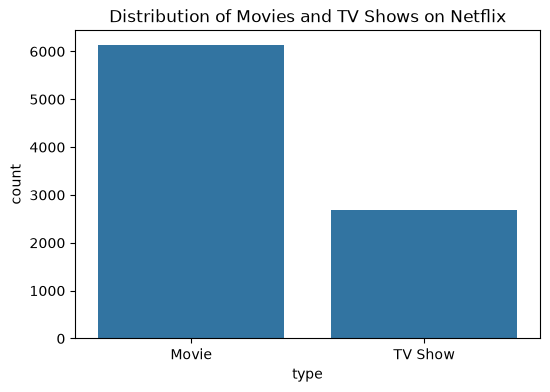

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.show()

In [7]:
(df['type'].value_counts(normalize=True) * 100).round(2)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

In [8]:
df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [13]:
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

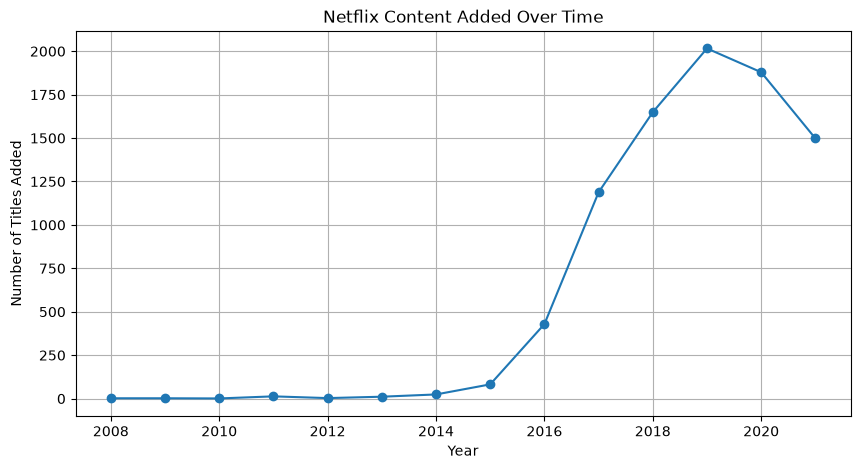

In [14]:
yearly_content = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(yearly_content.index, yearly_content.values, marker='o')

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.grid(True)

plt.show()

In [15]:
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

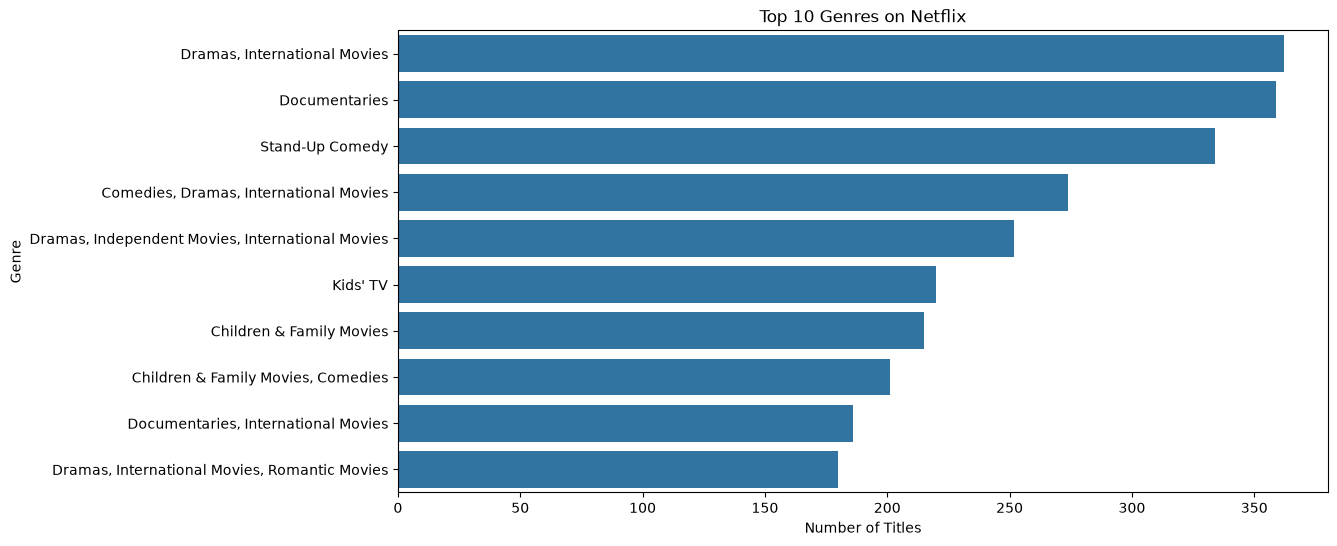

In [16]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [17]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

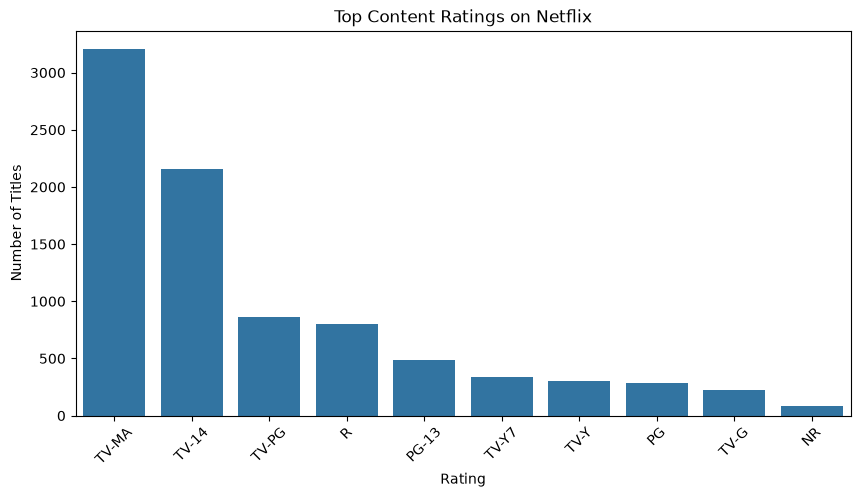

In [18]:
top_ratings = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_ratings.index, y=top_ratings.values)

plt.title("Top Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [19]:
df['release_year'].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [20]:
df['release_year'].value_counts().sort_index().tail(15)

release_year
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

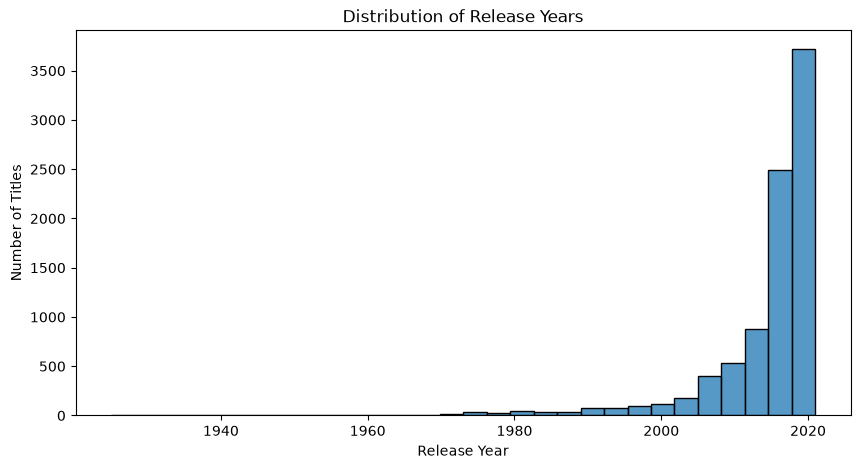

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df['release_year'], bins=30)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [22]:
df[df['director'] != 'Unknown']['director'].value_counts().head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

In [23]:
df['release_year'].value_counts().sort_index().tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

# Key Insights

1. Movies account for 69.62% of Netflix content.

2. The United States is the largest contributor with 2818 titles, followed by India with 972 titles.

3. Netflix experienced rapid content growth between 2015 and 2019.

4. Drama and International Movies are the most common genres.

5. TV-MA and TV-14 are the dominant content ratings, indicating a focus on mature and teenage audiences.

6. The majority of Netflix content was released after 2015.

7. Netflix maintains a highly diverse creator ecosystem with no single director dominating the platform.

In [24]:
df['content'] = df['listed_in'] + ' ' + df['description']
df[['title', 'content']].head()

,title,content
0,Dick Johnson Is Dead,Documentaries As her father nears the end of h...
1,Blood & Water,"International TV Shows, TV Dramas, TV Mysterie..."
2,Ganglands,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,"Docuseries, Reality TV Feuds, flirtations and ..."
4,Kota Factory,"International TV Shows, Romantic TV Shows, TV ..."


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['content'])

In [26]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [27]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [34]:
def recommend(title, cosine_sim=cosine_sim):

    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:6]

    movie_indices = [i[0] for i in sim_scores]

    return df[['title', 'type', 'listed_in']].iloc[movie_indices]

In [35]:
recommend('Narcos')

,title,type,listed_in
7463,Miss Dynamite,TV Show,"Crime TV Shows, International TV Shows, Spanis..."
2921,Narcos: Mexico,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas"
6673,El Cartel 2,TV Show,"Crime TV Shows, International TV Shows, Spanis..."
4750,El Chapo,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ..."
2,Ganglands,TV Show,"Crime TV Shows, International TV Shows, TV Act..."
